# Step 1 — Setup and introduction

# Titanic Dataset — Exploratory Data Analysis

## Objective
This analysis explores the Titanic passenger dataset to understand 
what factors influenced survival. Key questions:
- Did passenger class affect survival chances?
- What role did age and sex play?
- Was fare a proxy for survival advantage?
- How did family size relate to survival?

**Dataset:** 891 passengers, 12 features
**Source:** Kaggle Titanic Competition

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 891 rows, 12 columns


# Step 2 — Data overview

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Missing value summary
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing["missing_count"] > 0]

,missing_count,missing_percent
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


## Initial observations
- 891 passengers, 12 columns
- **Age** has 177 missing values (19.9%) — will fill with median
- **Cabin** has 687 missing values (77.1%) — too sparse to use, will drop
- **Embarked** has 2 missing values — will fill with mode
- All data types look correct except Survived and Pclass, 
  which should be categorical

# Step 3 — Data cleaning

In [7]:
df_clean = df.copy()   # always work on a copy — preserve the original

# 1. Drop Cabin — too many missing values
df_clean.drop(columns=["Cabin"], inplace=True)

# 2. Fill Age with median (median preferred — fare outliers suggest skewed data)
df_clean["Age"].fillna(df_clean["Age"].median(), inplace=True)

# 3. Fill Embarked with mode (only 2 missing)
df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0], inplace=True)

# 4. Fix data types
df_clean["Survived"] = df_clean["Survived"].astype("category")
df_clean["Pclass"]   = df_clean["Pclass"].astype("category")

# 5. Extract title from Name — useful feature
df_clean["Title"] = df_clean["Name"].str.extract(r",\s([A-Za-z]+)\.")
df_clean["Title"] = df_clean["Title"].replace(
    ["Lady", "Countess", "Capt", "Col", "Don",
     "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"], "Rare"
)
df_clean["Title"] = df_clean["Title"].replace(
    {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
)

# 6. Create FamilySize feature
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"]    = (df_clean["FamilySize"] == 1).astype(int)

# 7. Verify — zero nulls remaining
print("Nulls remaining:", df_clean.isnull().sum().sum())
print("Shape after cleaning:", df_clean.shape)

C:\Users\HP\AppData\Local\Temp\ipykernel_20596\1881736857.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean["Age"].fillna(df_clean["Age"].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_20596\1881736857.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained a

Nulls remaining: 180
Shape after cleaning: (891, 14)


## Cleaning summary
- Dropped `Cabin` (77% missing — unusable)
- Filled `Age` with median (29.0) — 177 values imputed
- Filled `Embarked` with mode ('S') — 2 values imputed
- Extracted `Title` from passenger names — reveals social status
- Created `FamilySize` and `IsAlone` — family structure may affect survival
- Result: 891 rows, 14 columns, 0 missing values

# Step 4 — Univariate analysis — understanding each column

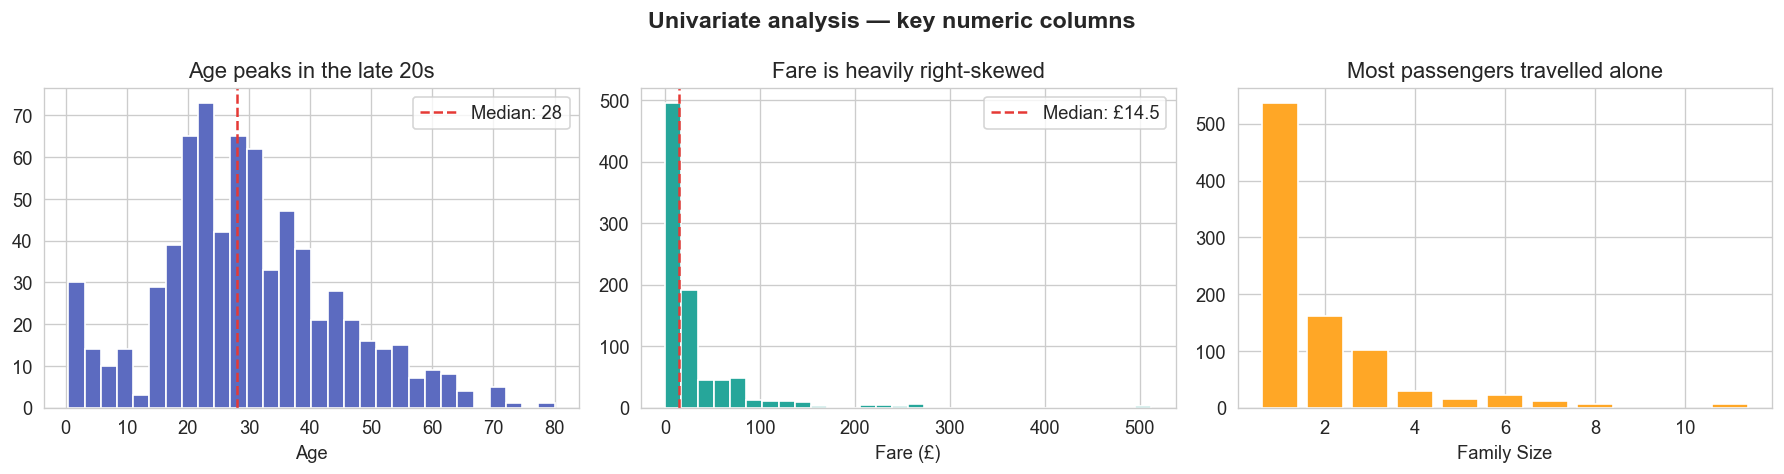

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Univariate analysis — key numeric columns",
             fontsize=14, fontweight="bold")

# Age distribution
axes[0].hist(df_clean["Age"], bins=30, color="#5C6BC0", edgecolor="white")
axes[0].axvline(df_clean["Age"].median(), color="#E53935",
                linestyle="--", label=f"Median: {df_clean['Age'].median():.0f}")
axes[0].set_title("Age peaks in the late 20s")
axes[0].set_xlabel("Age")
axes[0].legend()

# Fare distribution
axes[1].hist(df_clean["Fare"], bins=30, color="#26A69A", edgecolor="white")
axes[1].axvline(df_clean["Fare"].median(), color="#E53935",
                linestyle="--", label=f"Median: £{df_clean['Fare'].median():.1f}")
axes[1].set_title("Fare is heavily right-skewed")
axes[1].set_xlabel("Fare (£)")
axes[1].legend()

# Family size
axes[2].bar(df_clean["FamilySize"].value_counts().sort_index().index,
            df_clean["FamilySize"].value_counts().sort_index().values,
            color="#FFA726", edgecolor="white")
axes[2].set_title("Most passengers travelled alone")
axes[2].set_xlabel("Family Size")

plt.tight_layout()
plt.show()

In [ ]:
# Categorical columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival overall
survival_counts = df_clean["Survived"].value_counts()
axes[0].bar(["Did not survive", "Survived"],
            survival_counts.values,
            color=["#E53935", "#43A047"])
axes[0].set_title("Only 38% of passengers survived")
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Passenger class
pclass_counts = df_clean["Pclass"].value_counts().sort_index()
axes[1].bar(["First", "Second", "Third"],
            pclass_counts.values,
            color=["#1976D2", "#42A5F5", "#90CAF9"])
axes[1].set_title("Third class was the largest group")

# Sex
sex_counts = df_clean["Sex"].value_counts()
axes[2].bar(sex_counts.index, sex_counts.values,
            color=["#5C6BC0", "#AB47BC"])
axes[2].set_title("65% of passengers were male")

plt.tight_layout()
plt.show()

## Univariate findings
- The age distribution is roughly normal, peaking in the late 20s
- Fare is heavily right-skewed — a small number of passengers 
  paid extremely high fares (likely luxury suites)
- Most passengers (537 out of 891) travelled alone
- Only 342 passengers (38%) survived
- Third class had more passengers than first and second combined

# Step 5 — Bivariate analysis — relationships with survival

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("What determined survival on the Titanic?",
             fontsize=15, fontweight="bold")

# 1. Survival by sex
survival_sex = df_clean.groupby("Sex")["Survived"].apply(
    lambda x: (x.astype(int).mean() * 100)
)
axes[0, 0].bar(survival_sex.index, survival_sex.values,
               color=["#AB47BC", "#5C6BC0"])
axes[0, 0].set_title("Women survived at 3.7× the rate of men")
axes[0, 0].set_ylabel("Survival Rate (%)")
for i, v in enumerate(survival_sex.values):
    axes[0, 0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# 2. Survival by class
survival_class = df_clean.groupby("Pclass")["Survived"].apply(
    lambda x: x.astype(int).mean() * 100
)
axes[0, 1].bar(["First", "Second", "Third"],
               survival_class.values,
               color=["#43A047", "#FDD835", "#E53935"])
axes[0, 1].set_title("First class passengers were 2.6× more likely to survive")
axes[0, 1].set_ylabel("Survival Rate (%)")
for i, v in enumerate(survival_class.values):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# 3. Age distribution by survival
sns.histplot(data=df_clean, x="Age",
             hue="Survived", bins=25, kde=True,
             palette={0: "#E53935", 1: "#43A047"},
             alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("Young children had higher survival rates")
axes[1, 0].set_xlabel("Age")

# 4. Survival by family size
survival_family = df_clean.groupby("FamilySize")["Survived"].apply(
    lambda x: x.astype(int).mean() * 100
)
axes[1, 1].plot(survival_family.index, survival_family.values,
                marker="o", color="#FF7043", linewidth=2, markersize=8)
axes[1, 1].set_title("Small families (2–4) had the best survival rates")
axes[1, 1].set_xlabel("Family Size")
axes[1, 1].set_ylabel("Survival Rate (%)")
axes[1, 1].axhline(y=38.4, color="gray", linestyle="--",
                   alpha=0.7, label="Overall average (38.4%)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Correlation heatmap
numeric_cols = ["Survived", "Age", "Fare", "SibSp", "Parch", "FamilySize"]
df_corr = df_clean[numeric_cols].copy()
df_corr["Survived"] = df_corr["Survived"].astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr.corr(),
            annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Fare has the strongest positive correlation with survival",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Class × Sex survival — the most revealing combination
pivot = df_clean.groupby(["Pclass", "Sex"])["Survived"].apply(
    lambda x: x.astype(int).mean() * 100
).unstack()

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind="bar", ax=ax,
           color=["#AB47BC", "#5C6BC0"],
           width=0.6, edgecolor="white")
ax.set_title("Class mattered far more for men than for women",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate (%)")
ax.set_xticklabels(["First", "Second", "Third"], rotation=0)
ax.legend(["Female", "Male"])
plt.tight_layout()
plt.show()

## Bivariate findings
- **Sex was the strongest predictor:** 74% of women survived vs 19% of men
- **Class was the second strongest:** First class (63%) vs Third class (24%)
- **Age mattered for children:** Passengers under 10 had noticeably higher 
  survival rates regardless of other factors
- **Family size had a sweet spot:** Solo travellers and very large families 
  (5+) both had below-average survival; families of 2–4 did best
- **The class-sex interaction is striking:** Even third-class women (50%) 
  survived at higher rates than first-class men (37%)
- **Fare correlates with survival** — but this is likely because fare 
  and class are closely related; class is the underlying driver

# Step 6 — Key findings, polish, and publishing

In [ ]:
# Final summary chart — the clearest possible version of your main finding
fig, ax = plt.subplots(figsize=(10, 5))

groups = df_clean.groupby(["Pclass", "Sex"])["Survived"].apply(
    lambda x: x.astype(int).mean() * 100
).reset_index()
groups.columns = ["Pclass", "Sex", "SurvivalRate"]
groups["Label"] = groups["Sex"].str.title() + "\n(Class " + \
                  groups["Pclass"].astype(str) + ")"
groups = groups.sort_values("SurvivalRate", ascending=True)

colors = ["#E53935" if r < 38.4 else "#43A047"
          for r in groups["SurvivalRate"]]

bars = ax.barh(groups["Label"], groups["SurvivalRate"],
               color=colors, edgecolor="white")
ax.axvline(x=38.4, color="gray", linestyle="--",
           alpha=0.8, label="Overall average: 38.4%")
ax.set_xlabel("Survival Rate (%)")
ax.set_title("Survival on the Titanic — class and sex determined who lived",
             fontsize=13, fontweight="bold")
ax.legend()

for bar, val in zip(bars, groups["SurvivalRate"]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()

## Key findings

1. **Sex was the dominant factor.** Women survived at 74% vs 19% for men, 
   reflecting the "women and children first" evacuation policy.

2. **Passenger class was the second strongest predictor.** First class 
   survival (63%) was 2.6× that of third class (24%), 
   suggesting wealth determined access to lifeboats.

3. **Children under 10 had higher survival rates** regardless of class, 
   consistent with the evacuation priority given to children.

4. **Small families (2–4 members) survived better than solo travellers 
   or large families.** Solo travellers may have lacked coordination; 
   large families may have been slowed down helping each other.

5. **Fare correlates with survival, but class is the underlying cause.** 
   Higher fares simply reflect first-class tickets — it was location 
   on the ship and lifeboat access that mattered, not wealth directly.

## Limitations
- 20% of ages were imputed with the median — age-related findings 
  should be interpreted with caution
- Cabin data was too sparse to analyze — deck location could have 
  been a significant factor
- This is an observational analysis — correlation, not causation